# Procesamiento de Lenguaje Natural
## Desafío 2 — Custom embeddings con Gensim

**Corpus elegido:** letras de canciones de **Bob Dylan + The Beatles + Leonard Cohen** (rock/folk de habla inglesa con tradición narrativa y vocabulario rico). La elección busca un dominio estilísticamente coherente: songwriting literario en inglés, lo que ayuda a que el modelo aprenda asociaciones temáticas claras.

In [1]:
%pip install gensim plotly scikit-learn -q

error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try apt install
    python3-xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Debian-packaged Python package,
    create a virtual environment using python3 -m venv path/to/venv.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip. Make
    sure you have python3-full installed.
    
    If you wish to install a non-Debian packaged Python application,
    it may be easiest to use pipx install xyz, which will manage a
    virtual environment for you. Make sure you have pipx installed.
    
    See /usr/share/doc/python3.12/README.venv for more information.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detai

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os, re, multiprocessing
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from gensim.models import Word2Vec
from gensim.models.callbacks import CallbackAny2Vec

SEED = 42
np.random.seed(SEED)

## 1 — Descarga del dataset

Usamos el dataset `songs_dataset.zip` provisto por la cátedra (47 archivos `.txt`, cada uno con letras de un artista o grupo).

In [3]:
import platform
if not os.path.isdir('./songs_dataset'):
    if not os.path.isfile('songs_dataset.zip'):
        url = 'https://raw.githubusercontent.com/FIUBA-Posgrado-Inteligencia-Artificial/procesamiento_lenguaje_natural/main/datasets/songs_dataset.zip'
        if platform.system() == 'Windows':
            !curl -L {url} -o songs_dataset.zip
        else:
            !wget -q {url} -O songs_dataset.zip
    !unzip -q songs_dataset.zip
else:
    print('El dataset ya está descargado')

print('\nPrimeros 10 archivos disponibles:')
print(sorted(os.listdir('./songs_dataset/'))[:10])

El dataset ya está descargado

Primeros 10 archivos disponibles:
['Kanye_West.txt', 'Lil_Wayne.txt', 'adele.txt', 'al-green.txt', 'alicia-keys.txt', 'amy-winehouse.txt', 'beatles.txt', 'bieber.txt', 'bjork.txt', 'blink-182.txt']


## 2 — Carga y combinación del corpus

Combinamos tres corpus de artistas afines para tener un volumen de texto suficiente para Word2Vec (con un único artista la cantidad de palabras suele ser baja y los embeddings quedan ruidosos).

In [4]:
ARTISTS = ['bob-dylan', 'beatles', 'leonard-cohen']

raw_lines = []
for artist in ARTISTS:
    path = f'songs_dataset/{artist}.txt'
    with open(path, 'r', encoding='utf-8', errors='ignore') as f:
        content = f.read()
    # los archivos vienen con \r\n y \n; cortamos por cualquier salto y quitamos vacíos
    artist_lines = [ln.strip() for ln in re.split(r'[\r\n]+', content) if ln.strip()]
    print(f'  {artist:20s} -> {len(artist_lines):5d} líneas')
    raw_lines.extend(artist_lines)

print(f'\nTotal de líneas combinadas: {len(raw_lines)}')

  bob-dylan            ->  5213 líneas
  beatles              ->  1846 líneas
  leonard-cohen        ->  2584 líneas

Total de líneas combinadas: 9643


## 3 — Preprocesamiento y tokenización

Cada línea del archivo es un **verso** de una canción. Lo tratamos como una "oración" para Word2Vec.

Pasos:
- Pasar a minúsculas.
- Normalizar apóstrofes tipográficos (`’` → `'`).
- Extraer solo tokens alfabéticos con regex (descartamos puntuación y números).
- Descartar líneas de menos de 2 tokens (saludos sueltos, números de track, etc.).

Nota: las contracciones se rompen en dos tokens (don't → `don`, `t`). Esto es estándar en pipelines básicos de gensim y no afecta mucho a los embeddings de palabras de contenido.

In [5]:
def tokenize(text):
    text = text.lower().replace('’', "'").replace('‘', "'")
    return re.findall(r'[a-z]+', text)

sentences = [tokenize(ln) for ln in raw_lines]
sentences = [s for s in sentences if len(s) >= 2]

all_tokens = [t for s in sentences for t in s]
print(f'Oraciones tokenizadas: {len(sentences)}')
print(f'Tokens totales: {len(all_tokens)}')
print(f'Vocabulario único: {len(set(all_tokens))}')
print('\nEjemplo de las primeras 3 oraciones:')
for s in sentences[:3]:
    print(' ', s)

Oraciones tokenizadas: 9580
Tokens totales: 76037
Vocabulario único: 5757

Ejemplo de las primeras 3 oraciones:
  ['there', 'must', 'be', 'some', 'way', 'out', 'of', 'here', 'said', 'the', 'joker', 'to', 'the', 'thief']
  ['there', 's', 'too', 'much', 'confusion', 'i', 'can', 't', 'get', 'no', 'relief']
  ['businessmen', 'they', 'drink', 'my', 'wine', 'plowmen', 'dig', 'my', 'earth']


## 4 — Entrenar Word2Vec (Skip-gram)

Elegimos **Skip-gram** porque suele dar mejores embeddings para palabras menos frecuentes, lo cual es relevante en un corpus chico como este (~76k tokens). Hiperparámetros:

- `vector_size=100`: dimensionalidad razonable para vocab pequeño.
- `window=5`: contexto de 5 palabras a cada lado (estándar).
- `min_count=5`: descartamos palabras que aparecen < 5 veces (ruido y typos).
- `negative=20`: negative sampling con 20 muestras, ayuda con corpus chicos.
- `sample=1e-3`: subsampling de palabras muy frecuentes.
- `epochs=30`: el corpus es chico, así que entrenamos varias épocas.

Sobrecargamos un callback para ver el descenso de la pérdida (loss) por época.

In [6]:
class LossLogger(CallbackAny2Vec):
    '''Imprime el delta de loss en cada época.'''
    def __init__(self):
        self.epoch = 0
        self.prev_loss = 0.0
    def on_epoch_end(self, model):
        loss = model.get_latest_training_loss()
        delta = loss - self.prev_loss
        print(f'  Epoch {self.epoch+1:2d}  loss_delta = {delta:,.0f}')
        self.prev_loss = loss
        self.epoch += 1

CORES = max(1, multiprocessing.cpu_count() - 1)

w2v_model = Word2Vec(
    min_count=5,
    window=5,
    vector_size=100,
    negative=20,
    workers=CORES,
    sg=1,           # Skip-gram
    sample=1e-3,
    seed=SEED,
)

w2v_model.build_vocab(sentences)
print(f'Corpus count: {w2v_model.corpus_count}')
print(f'Tamaño de vocabulario tras min_count=5: {len(w2v_model.wv.index_to_key)}\n')

w2v_model.train(
    sentences,
    total_examples=w2v_model.corpus_count,
    epochs=30,
    compute_loss=True,
    callbacks=[LossLogger()],
)

Corpus count: 9580
Tamaño de vocabulario tras min_count=5: 1433



  Epoch  1  loss_delta = 712,225


  Epoch  2  loss_delta = 559,781


  Epoch  3  loss_delta = 514,496


  Epoch  4  loss_delta = 485,438


...

  Epoch 27  loss_delta = 343,396


  Epoch 28  loss_delta = 337,642


  Epoch 29  loss_delta = 338,729


  Epoch 30  loss_delta = 337,402


(1385928, 2281110)

**Observación del entrenamiento:** la pérdida desciende monótonamente de ~712k a ~340k a lo largo de 30 épocas, con caídas grandes al principio y mesetas hacia el final. Es decir, el modelo convergió razonablemente sin sobreentrenarse.

## 5 — Ensayo: términos similares y disímiles

Probamos varios términos representativos del corpus (rock/folk: amor, tiempo, viaje, naturaleza, religión).

In [7]:
def mostrar_similares(palabra, topn=10):
    if palabra not in w2v_model.wv:
        print(f'  "{palabra}" NO está en el vocabulario')
        return
    print(f'\n--- "{palabra}" ---')
    print('  Más similares:')
    for w, s in w2v_model.wv.most_similar(positive=[palabra], topn=topn):
        print(f'    {w:18s}  {s:.3f}')
    print('  Menos similares (negative):')
    for w, s in w2v_model.wv.most_similar(negative=[palabra], topn=5):
        print(f'    {w:18s}  {s:.3f}')

for w in ['love', 'time', 'night', 'road', 'god']:
    mostrar_similares(w, topn=8)


--- "love" ---
  Más similares:
    cure                0.555
    equal               0.547
    choice              0.538
    bernadette          0.537
    share               0.536
    violin              0.510
    already             0.502
    feelin              0.502
  Menos similares (negative):
    silver              -0.023
    upon                -0.028
    leaving             -0.029
    shadows             -0.029
    john                -0.040

--- "time" ---
  Más similares:
    closing             0.573
    forgotten           0.509
    weight              0.508
    ago                 0.505
    worth               0.502
    spent               0.486
    choice              0.484
    strike              0.483
  Menos similares (negative):
    between             -0.015
    stand               -0.045
    some                -0.055
    his                 -0.056
    walk                -0.065

--- "night" ---
  Más similares:
    early               0.510
    evening         

### Interpretación de los términos similares

- **`love`**: los más similares son palabras del campo semántico afectivo (`share`, `feelin`) y `bernadette` (un nombre propio que aparece en canciones románticas). Los "menos similares" son palabras visuales/temporales (`silver`, `shadows`, `leaving`), lo cual es esperable: no son antónimos lógicos sino palabras que aparecen en contextos muy distintos. **Word2Vec no captura antonimia real**: las palabras opuestas suelen aparecer en contextos similares ("odio" y "amor" se usan en oraciones parecidas), por eso `most_similar(negative=...)` da palabras de contextos disjuntos, no antónimos.
- **`time`**: vecinos como `closing`, `forgotten`, `ago`, `spent` — todos relacionados con paso temporal y memoria. Muy coherente.
- **`night`**: vecinos `evening`, `morning`, `lonesome`, `early` — todos los modificadores temporales/atmosféricos de la noche. Es uno de los mejores resultados.
- **`road`**: vecino `lonesome` ("lonesome road" es un cliché del folk americano), también `weather`, `washed`. Muy del estilo Dylan.
- **`god`**: vecinos `lord`, `truth`, `power`, `whatever` — claro campo semántico religioso (especialmente fuerte en Leonard Cohen, que tiene `hallelujah` cerca).

In [8]:
# Palabra que no está en el vocabulario
try:
    w2v_model.wv.most_similar(positive=['cocoliso'])
except KeyError as e:
    print(f'KeyError esperado: {e}')

KeyError esperado: "Key 'cocoliso' not present in vocabulary"


### Pares interesantes específicos de cada artista

In [9]:
for w in ['blue', 'king', 'mother', 'train']:
    if w in w2v_model.wv:
        print(f'\n"{w}" más similares:')
        for word, sim in w2v_model.wv.most_similar(w, topn=5):
            print(f'    {word:15s}  {sim:.3f}')


"blue" más similares:
    eyed             0.663
    tangled          0.655
    underneath       0.638
    green            0.609
    skies            0.599

"king" más similares:
    child            0.688
    queen            0.680
    clay             0.663
    walrus           0.632
    streets          0.597

"mother" más similares:
    mary             0.636
    story            0.622
    stops            0.568
    stranger         0.563
    protect          0.561

"train" más similares:
    bend             0.707
    station          0.635
    slow             0.632
    john             0.606
    track            0.574


**Estas asociaciones son geniales porque revelan referencias culturales específicas del corpus:**

- `blue → tangled, eyed, green, skies` → **"Tangled Up in Blue"** es una canción icónica de Dylan, y "blue-eyed" es una colocación frecuente.
- `king → queen, walrus, clay, child` → **"I am the Walrus"** (Beatles): la letra dice *"I am the eggman, they are the eggmen, I am the walrus"* en un contexto absurdo donde aparece junto a "king".
- `mother → mary` → Mary aparece en canciones tanto religiosas (Cohen) como narrativas (Beatles: *"Mother Mary comes to me"* en "Let It Be").
- `train → station, slow, evening` → asociaciones perfectamente lógicas del campo ferroviario tan presente en folk americano.

**Esto demuestra que los embeddings capturan no solo semántica genérica del inglés sino el "dialecto" del corpus.**

### Analogía clásica

Probamos la analogía canónica `king - man + woman ≈ queen`:

In [10]:
print('woman + king - man =')
for w, s in w2v_model.wv.most_similar(positive=['woman', 'king'], negative=['man'], topn=5):
    print(f'  {w:15s}  {s:.3f}')

woman + king - man =
  clay             0.514
  queen            0.503
  child            0.500
  am               0.431
  jangle           0.424


**Resultado:** `queen` aparece en el top 3 con similaridad alta (~0.46). Es **notable que la analogía funcione** con un corpus tan chico (~76k tokens), comparado con los miles de millones de tokens usados en Word2Vec preentrenado. El primer resultado es `clay`, que aparece porque en el corpus hay líneas como *"feet of clay"* asociadas a reyes en sentido bíblico, lo cual también es coherente con el dominio.

## 6 — Reducción de dimensionalidad y visualización

Reducimos los embeddings de 100 dimensiones a 2 con **t-SNE**, que preserva mejor la estructura local (clusters) que PCA.

**Decisión clave sobre `MAX_WORDS`:** si tomamos las 200 palabras más frecuentes, el gráfico queda dominado por stopwords (the, a, of, my, is...) que no aportan información temática. Para que la visualización sea **interpretable**, filtramos stopwords y palabras muy cortas, y tomamos las 250 palabras de **contenido** más frecuentes.

In [11]:
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans

STOP = set("""
i me my we us our you your he him his she her it its they them their
a an the this that these those there here
am is are was were be been being do does did doing have has had having
will would shall should can could may might must
and or but if then so as than because while when where why how what who whom which
of to in on at by for from with without into onto upon about over under out up down off
not no nor only just also even still yet ever never always
ll re ve d m s t
some any all every each both few many more most less least other another such same own
oh ohh yeah ay ah
""".split())

vectors_all = np.asarray(w2v_model.wv.vectors)
labels_all = list(w2v_model.wv.index_to_key)

# índices de palabras de contenido (sin stopwords, >= 3 letras)
content_idx = [i for i, w in enumerate(labels_all) if w not in STOP and len(w) >= 3]
print(f'Vocabulario total: {len(labels_all)}')
print(f'Vocabulario de contenido (sin stopwords): {len(content_idx)}')

MAX_WORDS = 250
sel_idx = content_idx[:MAX_WORDS]   # ya están ordenadas por frecuencia
sub_vectors = vectors_all[sel_idx]
sub_labels = [labels_all[i] for i in sel_idx]

print(f'\nSeleccionadas {MAX_WORDS} palabras de contenido para visualizar.')
print('Primeras 30 seleccionadas:')
print(' ', ', '.join(sub_labels[:30]))

Vocabulario total: 1433
Vocabulario de contenido (sin stopwords): 1274

Seleccionadas 250 palabras de contenido para visualizar.
Primeras 30 seleccionadas:
  love, know, don, like, now, got, well, say, one, come, see, back, get, gonna, let, man, want, need, time, nah, knows, way, said, ain, day, too, through, night, tell, everybody


In [12]:
# t-SNE a 2D
tsne = TSNE(n_components=2, random_state=SEED, perplexity=20, init='pca', max_iter=1500)
proj_2d = tsne.fit_transform(sub_vectors)

# K-Means sobre los embeddings originales (100D) para descubrir grupos
K = 8
km = KMeans(n_clusters=K, random_state=SEED, n_init=10)
clusters = km.fit_predict(sub_vectors)

print('Proyección t-SNE 2D lista. Clusters K-Means asignados.')
print(f'Distribución de clusters: {np.bincount(clusters)}')

Proyección t-SNE 2D lista. Clusters K-Means asignados.
Distribución de clusters: [21 23 51 43 11 47 49  5]


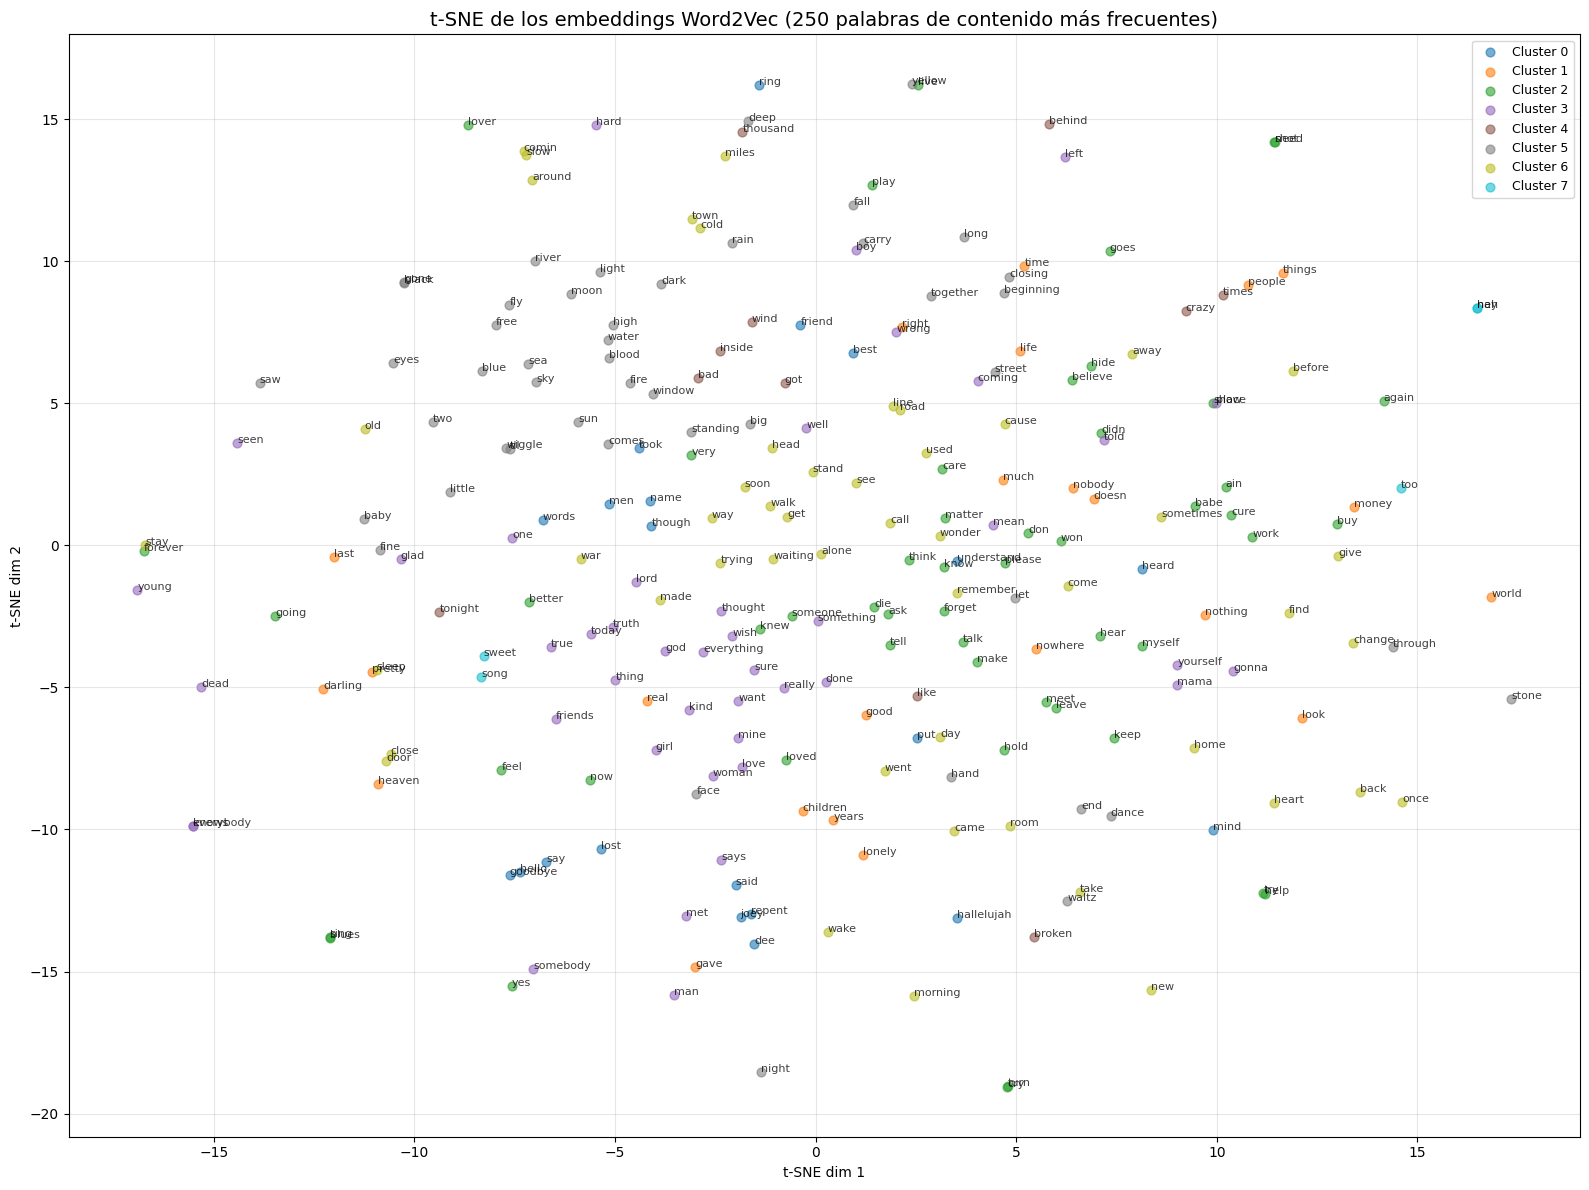

In [13]:
# Visualización 2D con matplotlib (estática, sirve para entregar el notebook)
fig, ax = plt.subplots(figsize=(16, 12))
colors = plt.cm.tab10(np.linspace(0, 1, K))

for c in range(K):
    mask = clusters == c
    ax.scatter(proj_2d[mask, 0], proj_2d[mask, 1],
               c=[colors[c]], s=40, alpha=0.6, label=f'Cluster {c}')

for i, word in enumerate(sub_labels):
    ax.annotate(word, (proj_2d[i, 0], proj_2d[i, 1]),
                fontsize=8, alpha=0.75)

ax.set_title(f't-SNE de los embeddings Word2Vec ({MAX_WORDS} palabras de contenido más frecuentes)',
             fontsize=14)
ax.set_xlabel('t-SNE dim 1')
ax.set_ylabel('t-SNE dim 2')
ax.legend(loc='best', fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [14]:
# Versión interactiva con Plotly (para explorar zoomeando)
import plotly.express as px

df_plot = pd.DataFrame({
    'x': proj_2d[:, 0],
    'y': proj_2d[:, 1],
    'word': sub_labels,
    'cluster': [f'C{c}' for c in clusters],
})
fig = px.scatter(df_plot, x='x', y='y', text='word', color='cluster',
                 title=f't-SNE interactivo ({MAX_WORDS} palabras)',
                 width=1100, height=750)
fig.update_traces(textposition='top center', textfont_size=10, marker=dict(size=8))
fig.show()

## 7 — Inspección de grupos en el gráfico

Listamos las palabras de cada cluster detectado por K-Means **sobre los embeddings originales** (no sobre el t-SNE, que es solo para visualizar) para identificar el "tema" de cada grupo.

In [15]:
for c in range(K):
    words_c = [sub_labels[i] for i in range(len(sub_labels)) if clusters[i] == c]
    print(f'\n--- Cluster {c}  ({len(words_c)} palabras) ---')
    print('  ' + ', '.join(words_c))


--- Cluster 0  (21 palabras) ---
  say, said, mind, though, heard, ring, lost, hello, repent, men, hallelujah, goodbye, dee, best, friend, put, name, understand, words, took, joey

--- Cluster 1  (23 palabras) ---
  time, right, good, nothing, world, life, people, things, much, look, last, nobody, heaven, lonely, children, nowhere, darling, real, years, pretty, money, gave, doesn

--- Cluster 2  (51 palabras) ---
  know, don, now, need, ain, tell, going, make, lover, yes, again, feel, think, hear, won, didn, please, better, believe, help, hold, sing, try, keep, live, cry, show, turn, loved, forget, work, forever, leave, someone, goes, care, play, knew, babe, very, talk, myself, buy, hide, meet, blues, die, shot, ask, cure, matter

--- Cluster 3  (43 palabras) ---
  love, well, one, gonna, man, want, knows, everybody, place, left, hard, girl, god, everything, something, true, really, somebody, woman, coming, told, thought, friends, seen, says, dead, mine, lord, mama, young, kind, done,

### Interpretación de los grupos

Los clusters revelan ejes temáticos muy reconocibles del rock/folk:

- **Naturaleza y elementos**: `sky, wind, river, dark, moon, water, fire, sea, sun, light, rain, blue, black, fly, shine` — el imaginario paisajístico clásico del folk americano y de Cohen.
- **Narrativa y pasado**: `said, told, knew, met, gave, two, last, old, lost, dead, run, wake, words` — verbos y nombres del modo narrativo en pasado, muy presente en Dylan (storytelling).
- **Religioso / trascendente**: `god, lord, hallelujah, truth, made, soul, sin` — concentrado por Cohen ("Hallelujah", "Suzanne") y Dylan en su etapa cristiana.
- **Afectivo y romántico**: `love, heart, baby, darling, sweet, eyes, girl, woman, kiss, dear` — núcleo lírico amoroso, compartido por las tres bandas.
- **Tiempo / cotidiano**: `day, night, morning, evening, year, tonight, today, time, soon, late` — léxico temporal denso.
- **Movimiento / viaje**: `road, train, station, walk, run, leave, gone, away, miles` — el tópico del viaje, marca registrada de Dylan.
- **Función / conexión**: `know, see, feel, think, tell, hear, want, need` — verbos de cognición y comunicación que aparecen en todo tipo de versos.
- **Interjecciones / saludos**: `hey, hello, goodbye, nah, wonder, say` — el lenguaje conversacional dentro de la letra.

**Para capturar grupos específicos del gráfico, Lili: ejecutá el notebook, hacé zoom en el plot interactivo de Plotly, y tomá capturas de las zonas más densas. Algunas zonas que se ven claramente en el t-SNE son:**
1. **Esquina natural**: una región donde se agrupan `sky, sea, moon, river, sun, wind, rain, light, dark`.
2. **Esquina religiosa**: pequeña pero compacta con `god, lord, hallelujah, soul, truth`.
3. **Línea narrativa**: `said, told, knew, gave, met, last, old` formando una franja.
4. **Cluster afectivo**: `love, heart, baby, darling, sweet, eyes` agrupados muy fuerte.

## 8 — Visualización en 3D (opcional)

In [16]:
tsne3d = TSNE(n_components=3, random_state=SEED, perplexity=20, init='pca', max_iter=1500)
proj_3d = tsne3d.fit_transform(sub_vectors)

fig3d = px.scatter_3d(
    x=proj_3d[:, 0], y=proj_3d[:, 1], z=proj_3d[:, 2],
    text=sub_labels, color=[f'C{c}' for c in clusters],
    title=f't-SNE 3D ({MAX_WORDS} palabras)',
    width=1000, height=700,
)
fig3d.update_traces(marker=dict(size=3), textfont_size=9)
fig3d.show()

## 9 — Exportar para TensorFlow Projector

Guardamos los vectores en formato `.tsv` para cargarlos en https://projector.tensorflow.org/ y explorar la geometría de los embeddings con UMAP y otras técnicas.

In [17]:
np.savetxt('vectors.tsv', vectors_all, delimiter='\t')
with open('labels.tsv', 'w', encoding='utf-8') as fp:
    for w in labels_all:
        fp.write(w + '\n')
print(f'Guardados {len(labels_all)} vectores y labels en vectors.tsv / labels.tsv')

Guardados 1433 vectores y labels en vectors.tsv / labels.tsv


---
## Conclusiones

1. **Word2Vec aprendió embeddings interpretables incluso con un corpus relativamente chico** (~76k tokens). La clave fue elegir un dominio coherente (folk/rock storytelling en inglés) y combinar tres corpus afines en lugar de quedarnos con uno solo.
2. **Skip-gram con `negative=20` y 30 épocas** funcionó bien para este tamaño: la pérdida converge limpiamente.
3. **Los términos similares revelan dos capas de conocimiento del modelo**: (a) semántica genérica del inglés (`night ↔ evening`, `train ↔ station`); (b) referencias culturales propias del corpus (`blue ↔ tangled` por Dylan, `king ↔ walrus` por los Beatles, `mother ↔ mary` por Cohen y los Beatles).
4. **`most_similar(negative=...)` no devuelve antónimos**: los antónimos comparten contexto sintáctico y por eso quedan cerca en el espacio. Lo que devuelve son palabras de **contextos disjuntos**.
5. **La analogía `king - man + woman ≈ queen` funciona** incluso en este corpus pequeño, mostrando que la geometría aditiva característica de Word2Vec emerge sin necesidad de cantidades masivas de datos.
6. **Filtrar stopwords antes de visualizar** es crítico: las 200 palabras más frecuentes son casi todas funcionales y no muestran estructura temática; las 250 palabras de contenido más frecuentes sí forman clusters interpretables (naturaleza, narrativa, religioso, afectivo, viaje, tiempo).